# Sprint 2 - Validacion completa de deteccion de valores unitarios atipicos

Objetivo principal:

1. Mantener el mismo protocolo base de la Semana 5 / Semana 6.
2. Validar que el split sea correcto por subpartida.
3. Asegurar que todos los ajustes se calculen solo con train.
4. Comparar baseline vs variantes mediante ablation study.
5. Evaluar estabilidad con cross-validation por subpartida.
6. Generar diagnosticos, logs, README y checklist final.

Idea clave del proyecto:

Cada subpartida se evalua como un universo independiente. No se deben mezclar distribuciones de productos diferentes para ajustar limites o validar resultados.

In [3]:
# =============================================================================
# 1. CONFIGURACION GENERAL
# =============================================================================

import hashlib
import json
import logging
import time
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.calibration import calibration_curve

from sqlalchemy import create_engine, text
from sqlalchemy.pool import NullPool

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# Semillas y parametros reproducibles
# -----------------------------------------------------------------------------
SEED = 42
np.random.seed(SEED)

# -----------------------------------------------------------------------------
# Conexion SQL Server
# Ajustar estos valores solo si cambia el ambiente local.
# -----------------------------------------------------------------------------
SERVIDOR = r"DESKTOP-OGU19A7\SQLEXPRESS,56878"
BASE_DATOS = "DB_GEE_DW_ADUANAS"
ESQUEMA = "SC_ADUANA"
PROCEDIMIENTO = "SP_VALORES_UNITARIOS"
DRIVER = "ODBC+Driver+17+for+SQL+Server"

# Periodo de evaluacion. No cambiar entre baseline y variantes.
FEC_INI = "2024-01-01"
FEC_FIN = "2024-12-31"

# -----------------------------------------------------------------------------
# Columnas esperadas
# -----------------------------------------------------------------------------
COL_GRUPO = "NUM_SPN_R"
COL_ADUANA = "ADUANA"
COL_FOB = "FOB_DOLAR"
COL_VU_ORIGEN = "MTO_VALOR_UNTARIO_V"
COL_FECHA_CANDIDATAS = [
    "FEC_NUM",
    "FECHA",
    "FEC_DECLARACION",
    "FECHA_DECLARACION",
]

# -----------------------------------------------------------------------------
# Parametros del experimento
# -----------------------------------------------------------------------------
TEST_SIZE = 0.30
UMBRAL_Z_ROBUSTO_GT = 3.5
MIN_REGISTROS_GRUPO = 20
N_FOLDS_CV = 5
MIN_REGISTROS_CV = 20
LEARNING_TRAIN_SIZES = [0.20, 0.40, 0.60, 0.80, 1.00]

# -----------------------------------------------------------------------------
# Carpetas de salida
# Nota: todos los CSV/TXT usan separador pipe y texto sin acentos.
# -----------------------------------------------------------------------------
OUTPUT_DIR = Path("outputs_sprint2")
LOGS_DIR = OUTPUT_DIR / "logs"
FIG_DIR = OUTPUT_DIR / "figuras"
DATA_DIR = OUTPUT_DIR / "datos"
for carpeta in [OUTPUT_DIR, LOGS_DIR, FIG_DIR, DATA_DIR]:
    carpeta.mkdir(parents=True, exist_ok=True)

SNAPSHOT_PATH = DATA_DIR / "snapshot_sprint2.csv"
LOG_EXPERIMENTOS_CSV = LOGS_DIR / "metrics_ablation_sprint2.csv"
LOG_CV_CSV = LOGS_DIR / "metrics_cv_sprint2.csv"
LOG_CV_SUBPARTIDA_CSV = LOGS_DIR / "metrics_cv_subpartida_sprint2.csv"
LOG_LEARNING_CSV = LOGS_DIR / "learning_curve_sprint2.csv"
LOG_IMPORTANCIA_CSV = LOGS_DIR / "feature_importance_sprint2.csv"
README_PATH = OUTPUT_DIR / "README_REPRODUCIBILIDAD.txt"
CHECKLIST_PATH = OUTPUT_DIR / "CHECKLIST_SPRINT2.txt"

# -----------------------------------------------------------------------------
# Logging
# -----------------------------------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
log = logging.getLogger("sprint2")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("CONFIGURACION LISTA")
print(f"Periodo: {FEC_INI} a {FEC_FIN}")
print(f"Seed: {SEED}")
print(f"Salida: {OUTPUT_DIR.resolve()}")

CONFIGURACION LISTA
Periodo: 2024-01-01 a 2024-12-31
Seed: 42
Salida: C:\Users\hp\Downloads\ROBOTICA\TESIS_2\notebooks\03_sprint2_semana7\outputs_sprint2


In [4]:
# =============================================================================
# 2. FUNCIONES BASE DE LECTURA, LIMPIEZA Y VALIDACION
# =============================================================================

def crear_motor_sql_server() -> object:
    """
    Crea el motor de conexion hacia SQL Server usando autenticacion integrada.

    Parameters
    ----------
    None
        La funcion usa las constantes globales SERVIDOR, BASE_DATOS y DRIVER.

    Returns
    -------
    object
        Motor SQLAlchemy configurado con NullPool.

    Raises
    ------
    RuntimeError
        Si no se puede construir el motor de conexion.
    """
    try:
        url = (
            f"mssql+pyodbc://{SERVIDOR}/{BASE_DATOS}"
            f"?driver={DRIVER}&Trusted_Connection=yes"
        )
        return create_engine(url, echo=False, poolclass=NullPool)
    except Exception as exc:
        raise RuntimeError(f"No se pudo crear el motor SQL Server: {exc}") from exc


def cargar_datos_sql_server() -> pd.DataFrame:
    """
    Ejecuta el procedimiento almacenado y devuelve el dataset base.

    Parameters
    ----------
    None
        La funcion usa las constantes globales de conexion y periodo.

    Returns
    -------
    pd.DataFrame
        Datos extraidos desde SQL Server.

    Raises
    ------
    RuntimeError
        Si el procedimiento no retorna filas o si falla la consulta.
    """
    sentencia = text(
        f"EXEC [{BASE_DATOS}].[{ESQUEMA}].[{PROCEDIMIENTO}] "
        f"@ACCION='EDA_BASE', @FEC_INI='{FEC_INI}', @FEC_FIN='{FEC_FIN}'"
    )

    try:
        motor = crear_motor_sql_server()
        with motor.connect() as conn:
            resultado = conn.execute(sentencia)
            df = pd.DataFrame.from_records(
                resultado.fetchall(),
                columns=list(resultado.keys()),
            )
    except Exception as exc:
        raise RuntimeError(f"Error al cargar datos desde SQL Server: {exc}") from exc

    if df.empty:
        raise RuntimeError("El procedimiento retorno 0 filas.")

    return df


def seleccionar_columna_fecha(df_raw: pd.DataFrame) -> str | None:
    """
    Identifica una columna de fecha disponible dentro del dataset.

    Parameters
    ----------
    df_raw : pd.DataFrame
        Dataset original extraido desde SQL Server.

    Returns
    -------
    str | None
        Nombre de la primera columna de fecha encontrada. Retorna None si no existe.
    """
    for col_fecha in COL_FECHA_CANDIDATAS:
        if col_fecha in df_raw.columns:
            return col_fecha
    return None


def preparar_dataset(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia columnas numericas, elimina registros no validos y crea variables base.

    Parameters
    ----------
    df_raw : pd.DataFrame
        Dataset original extraido desde SQL Server.

    Returns
    -------
    pd.DataFrame
        Dataset limpio con VU, LOG_VU, LOG_FOB y campos auxiliares.

    Raises
    ------
    ValueError
        Si faltan columnas requeridas o el dataset queda vacio.
    """
    columnas_requeridas = [COL_GRUPO, COL_ADUANA, COL_FOB, COL_VU_ORIGEN]
    faltantes = [col for col in columnas_requeridas if col not in df_raw.columns]
    if faltantes:
        raise ValueError(f"Columnas faltantes: {faltantes}")

    columnas_base = columnas_requeridas.copy()
    col_fecha = seleccionar_columna_fecha(df_raw)
    if col_fecha:
        columnas_base.append(col_fecha)

    df = df_raw[columnas_base].copy()
    df[COL_GRUPO] = df[COL_GRUPO].astype(str).str.strip()
    df[COL_ADUANA] = df[COL_ADUANA].astype(str).str.strip().str.upper()
    df["VU"] = pd.to_numeric(df[COL_VU_ORIGEN], errors="coerce")
    df[COL_FOB] = pd.to_numeric(df[COL_FOB], errors="coerce")

    if col_fecha:
        df["FECHA_EVAL"] = pd.to_datetime(df[col_fecha], errors="coerce")

    df = df.dropna(subset=[COL_GRUPO, COL_ADUANA, COL_FOB, "VU"])
    df = df[(df[COL_FOB] > 0) & (df["VU"] > 0)].copy()

    conteo_grupo = df[COL_GRUPO].value_counts()
    grupos_validos = conteo_grupo[conteo_grupo >= MIN_REGISTROS_GRUPO].index
    df = df[df[COL_GRUPO].isin(grupos_validos)].copy()

    if df.empty:
        raise ValueError("El dataset quedo vacio despues de la limpieza.")

    df["LOG_VU"] = np.log1p(df["VU"])
    df["LOG_FOB"] = np.log1p(df[COL_FOB])

    return df.reset_index(drop=True)


def calcular_hash_archivo(ruta: Path) -> str:
    """
    Calcula el hash SHA256 de un archivo.

    Parameters
    ----------
    ruta : Path
        Ruta del archivo a hashear.

    Returns
    -------
    str
        Hash SHA256 hexadecimal.

    Raises
    ------
    FileNotFoundError
        Si el archivo no existe.
    """
    if not ruta.exists():
        raise FileNotFoundError(f"No existe el archivo: {ruta}")

    sha256 = hashlib.sha256()
    with ruta.open("rb") as archivo:
        for bloque in iter(lambda: archivo.read(1024 * 1024), b""):
            sha256.update(bloque)
    return sha256.hexdigest()


def crear_etiqueta_proxy(df: pd.DataFrame) -> pd.DataFrame:
    """
    Crea una etiqueta proxy de outlier con z-score robusto por subpartida.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset limpio con columna LOG_VU.

    Returns
    -------
    pd.DataFrame
        Dataset con columnas MEDIANA_LOG_VU, MAD_LOG_VU, Z_ROBUSTO y y_true.

    Notes
    -----
    La etiqueta y_true es proxy estadistica. No reemplaza una validacion experta.
    """
    salida = df.copy()

    mediana = salida.groupby(COL_GRUPO)["LOG_VU"].transform("median")
    desviacion_abs = (salida["LOG_VU"] - mediana).abs()
    mad = desviacion_abs.groupby(salida[COL_GRUPO]).transform("median")
    mad = mad.replace(0, np.nan)

    salida["MEDIANA_LOG_VU"] = mediana
    salida["MAD_LOG_VU"] = mad
    salida["Z_ROBUSTO"] = 0.6745 * (salida["LOG_VU"] - mediana) / mad
    salida["Z_ROBUSTO"] = salida["Z_ROBUSTO"].replace([np.inf, -np.inf], np.nan).fillna(0)
    salida["y_true"] = (salida["Z_ROBUSTO"].abs() > UMBRAL_Z_ROBUSTO_GT).astype(int)

    return salida.reset_index(drop=True)

In [5]:
# =============================================================================
# 3. CARGA, LIMPIEZA Y SNAPSHOT DE DATA
# =============================================================================

inicio_carga = time.perf_counter()

try:
    df_raw = cargar_datos_sql_server()
    log.info("Datos cargados desde SQL Server: %s filas", len(df_raw))
except Exception as exc:
    raise RuntimeError(
        "No se pudo cargar la data. Revisa SERVIDOR, BASE_DATOS, ESQUEMA, "
        "PROCEDIMIENTO, DRIVER y permisos de SQL Server. Detalle: " + str(exc)
    ) from exc

df_eval = preparar_dataset(df_raw)
df_eval = crear_etiqueta_proxy(df_eval)

SNAPSHOT_COLS = [
    COL_GRUPO,
    COL_ADUANA,
    COL_FOB,
    "VU",
    "LOG_VU",
    "LOG_FOB",
    "Z_ROBUSTO",
    "y_true",
]

if "FECHA_EVAL" in df_eval.columns:
    SNAPSHOT_COLS.append("FECHA_EVAL")

df_eval[SNAPSHOT_COLS].to_csv(
    SNAPSHOT_PATH,
    index=False,
    sep="|",
    encoding="utf-8",
)
HASH_SNAPSHOT = calcular_hash_archivo(SNAPSHOT_PATH)

resumen_dataset = pd.DataFrame({
    "indicador": [
        "registros_limpios",
        "subpartidas",
        "aduanas",
        "outliers_proxy",
        "tasa_outlier_proxy",
        "hash_snapshot_sha256",
        "tiempo_carga_seg",
    ],
    "valor": [
        f"{len(df_eval):,}",
        f"{df_eval[COL_GRUPO].nunique():,}",
        f"{df_eval[COL_ADUANA].nunique():,}",
        f"{int(df_eval['y_true'].sum()):,}",
        f"{df_eval['y_true'].mean():.4f}",
        HASH_SNAPSHOT,
        f"{time.perf_counter() - inicio_carga:.2f}",
    ],
})

resumen_dataset

2026-05-29 19:04:30 | INFO | Datos cargados desde SQL Server: 390426 filas


,indicador,valor
0,registros_limpios,"388,440"
1,subpartidas,444
2,aduanas,16
3,outliers_proxy,"18,884"
4,tasa_outlier_proxy,0.0486
5,hash_snapshot_sha256,64e301537f11093ea2b54fd90fd4cb7c57825c226f3718...
6,tiempo_carga_seg,10.06


In [6]:
# =============================================================================
# 4. SPLIT CORRECTO POR SUBPARTIDA Y VALIDACION DEL SPLIT
# =============================================================================

def crear_split_por_subpartida(df_base: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, str]:
    """
    Crea train/test dentro de cada subpartida.

    Parameters
    ----------
    df_base : pd.DataFrame
        Dataset limpio con variables de evaluacion y columna y_true.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame, str]
        DataFrame de entrenamiento, DataFrame de prueba y descripcion del split.

    Raises
    ------
    ValueError
        Si faltan columnas necesarias o no hay subpartidas suficientes.
    """
    columnas_requeridas = [COL_GRUPO, "VU", "LOG_VU", "LOG_FOB", "y_true"]
    faltantes = [columna for columna in columnas_requeridas if columna not in df_base.columns]
    if faltantes:
        raise ValueError(f"Columnas faltantes para split: {faltantes}")

    lista_train = []
    lista_test = []
    subpartidas_omitidas = []

    for subpartida, df_sub in df_base.groupby(COL_GRUPO):
        df_sub = df_sub.copy().reset_index(drop=True)

        if len(df_sub) < 5:
            subpartidas_omitidas.append(str(subpartida))
            continue

        tiene_dos_clases = df_sub["y_true"].nunique() >= 2
        clase_minima = df_sub["y_true"].value_counts().min()

        if tiene_dos_clases and clase_minima >= 2:
            train_sub, test_sub = train_test_split(
                df_sub,
                test_size=TEST_SIZE,
                random_state=SEED,
                stratify=df_sub["y_true"],
            )
        else:
            train_sub, test_sub = train_test_split(
                df_sub,
                test_size=TEST_SIZE,
                random_state=SEED,
                shuffle=True,
            )

        lista_train.append(train_sub)
        lista_test.append(test_sub)

    if not lista_train or not lista_test:
        raise ValueError("No se pudo crear split por subpartida.")

    train = pd.concat(lista_train, ignore_index=True)
    test = pd.concat(lista_test, ignore_index=True)

    descripcion = (
        f"Split {int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)} "
        f"dentro de cada {COL_GRUPO}"
    )

    print(f"Subpartidas omitidas por pocos registros: {len(subpartidas_omitidas)}")
    return train, test, descripcion


def validar_split(train: pd.DataFrame, test: pd.DataFrame) -> pd.DataFrame:
    """
    Resume la distribucion de train/test por subpartida.

    Parameters
    ----------
    train : pd.DataFrame
        Dataset de entrenamiento.
    test : pd.DataFrame
        Dataset de prueba.

    Returns
    -------
    pd.DataFrame
        Tabla de control con registros y tasas de outlier por subpartida.
    """
    resumen_train = train.groupby(COL_GRUPO).agg(
        registros_train=("y_true", "size"),
        outliers_train=("y_true", "sum"),
        tasa_outlier_train=("y_true", "mean"),
    )

    resumen_test = test.groupby(COL_GRUPO).agg(
        registros_test=("y_true", "size"),
        outliers_test=("y_true", "sum"),
        tasa_outlier_test=("y_true", "mean"),
    )

    resumen = resumen_train.join(resumen_test, how="outer").fillna(0).reset_index()
    resumen["tipo_split"] = TIPO_SPLIT
    return resumen.sort_values(["registros_test", COL_GRUPO], ascending=[False, True])

train_df, test_df, TIPO_SPLIT = crear_split_por_subpartida(df_eval)
tabla_validacion_split = validar_split(train_df, test_df)

print("Split definido")
print("=" * 80)
print(f"Tipo split     : {TIPO_SPLIT}")
print(f"Train          : {len(train_df):,} filas")
print(f"Test           : {len(test_df):,} filas")
print(f"Subpartidas tr : {train_df[COL_GRUPO].nunique():,}")
print(f"Subpartidas te : {test_df[COL_GRUPO].nunique():,}")
print(f"Outlier train  : {train_df['y_true'].mean():.4f}")
print(f"Outlier test   : {test_df['y_true'].mean():.4f}")

tabla_validacion_split.head(20)

Subpartidas omitidas por pocos registros: 0
Split definido
Tipo split     : Split 70/30 dentro de cada NUM_SPN_R
Train          : 271,711 filas
Test           : 116,729 filas
Subpartidas tr : 444
Subpartidas te : 444
Outlier train  : 0.0485
Outlier test   : 0.0488


,NUM_SPN_R,registros_train,outliers_train,tasa_outlier_train,registros_test,outliers_test,tasa_outlier_test,tipo_split
384,"804400000-AGUACATES (PALTAS) , FRESCAS O SECAS",23949,177,0.007391,10264,76,0.007405,Split 70/30 dentro de cada NUM_SPN_R
403,"810400000-ARANDANOS ROJOS, MIRTILOS Y DEMAS FR...",19161,93,0.004854,8212,40,0.004871,Split 70/30 dentro de cada NUM_SPN_R
395,806100000-UVAS FRESCAS,18013,333,0.018487,7720,143,0.018523,Split 70/30 dentro de cada NUM_SPN_R
333,"709200000-ESPARRAGOS, FRESCOS O REFRIGERADOS",11077,53,0.004785,4748,23,0.004844,Split 70/30 dentro de cada NUM_SPN_R
346,7108120000-ORO EN LAS DEMAS FORMAS EN BRUTO,10143,1147,0.113083,4348,492,0.113155,Split 70/30 dentro de cada NUM_SPN_R
118,"1905310000-GALLETAS DULCES (CON ADICIÃ""N DE ED...",8852,676,0.076367,3794,290,0.076436,Split 70/30 dentro de cada NUM_SPN_R
390,805299000-DEMAS CLEMENTINAS. WILKINGS E HIBRID...,7018,182,0.025933,3008,78,0.025931,Split 70/30 dentro de cada NUM_SPN_R
385,"804502000-MANGOS Y MANGOSTANES, FRESCOS O SECOS",6876,5,0.000727,2947,2,0.000679,Split 70/30 dentro de cada NUM_SPN_R
265,"603199000-LOS DEMAS FLORES Y CAPULLOS FRESCOS,...",6870,218,0.031732,2945,93,0.031579,Split 70/30 dentro de cada NUM_SPN_R
326,"703100000-CEBOLLAS Y CHALOTES, FRESCOS O REFRI...",6761,319,0.047182,2898,137,0.047274,Split 70/30 dentro de cada NUM_SPN_R


## Validacion anti-leakage

En las siguientes funciones, todos los parametros se ajustan solo con `train_df`.

- Los limites IQR se calculan solo con train.
- Los percentiles P5 y P95 se calculan solo con train.
- El test solo recibe parametros ya aprendidos.
- La misma data base se conserva para baseline y variantes.

In [12]:
# =============================================================================
# 5. FUNCIONES ANTI-LEAKAGE PARA EXPERIMENTOS A/B
# =============================================================================

def ajustar_iqr_por_grupo(train: pd.DataFrame, valor_col: str) -> tuple[pd.DataFrame, tuple[float, float]]:
    """
    Ajusta limites IQR por grupo usando solo entrenamiento.

    Parameters
    ----------
    train : pd.DataFrame
        Datos de entrenamiento.
    valor_col : str
        Columna numerica usada para calcular IQR.

    Returns
    -------
    tuple[pd.DataFrame, tuple[float, float]]
        Tabla con limites por grupo y limites globales de respaldo.
    """
    limites = train.groupby(COL_GRUPO)[valor_col].quantile([0.25, 0.75]).unstack()
    limites.columns = ["q1", "q3"]
    limites["iqr"] = limites["q3"] - limites["q1"]
    limites["lim_inf"] = limites["q1"] - 1.5 * limites["iqr"]
    limites["lim_sup"] = limites["q3"] + 1.5 * limites["iqr"]
    limites = limites.reset_index()[[COL_GRUPO, "lim_inf", "lim_sup"]]

    q1_global = train[valor_col].quantile(0.25)
    q3_global = train[valor_col].quantile(0.75)
    iqr_global = q3_global - q1_global
    globales = (q1_global - 1.5 * iqr_global, q3_global + 1.5 * iqr_global)

    return limites, globales


def predecir_iqr(test: pd.DataFrame, valor_col: str, limites: pd.DataFrame, globales: tuple[float, float]) -> np.ndarray:
    """
    Predice outliers aplicando limites IQR ajustados en train.

    Parameters
    ----------
    test : pd.DataFrame
        Datos de evaluacion.
    valor_col : str
        Columna numerica evaluada.
    limites : pd.DataFrame
        Limites IQR por grupo calculados con train.
    globales : tuple[float, float]
        Limites globales de respaldo para grupos no vistos.

    Returns
    -------
    np.ndarray
        Vector binario de prediccion.
    """
    eval_df = test[[COL_GRUPO, valor_col]].merge(limites, on=COL_GRUPO, how="left")
    eval_df["lim_inf"] = eval_df["lim_inf"].fillna(globales[0])
    eval_df["lim_sup"] = eval_df["lim_sup"].fillna(globales[1])
    pred = (eval_df[valor_col] < eval_df["lim_inf"]) | (eval_df[valor_col] > eval_df["lim_sup"])
    return pred.astype(int).to_numpy()


def ajustar_winsor_por_grupo(train: pd.DataFrame) -> tuple[pd.DataFrame, tuple[float, float]]:
    """
    Ajusta percentiles P5 y P95 por grupo usando solo entrenamiento.

    Parameters
    ----------
    train : pd.DataFrame
        Dataset de entrenamiento.

    Returns
    -------
    tuple[pd.DataFrame, tuple[float, float]]
        Tabla de limites por subpartida y limites globales P5/P95.
    """
    limites = train.groupby(COL_GRUPO)["VU"].quantile([0.05, 0.95]).unstack()
    limites.columns = ["p5", "p95"]
    limites = limites.reset_index()
    globales = (train["VU"].quantile(0.05), train["VU"].quantile(0.95))
    return limites, globales


def aplicar_winsor(df_base: pd.DataFrame, limites: pd.DataFrame, globales: tuple[float, float]) -> pd.Series:
    """
    Aplica winsorizacion con parametros ajustados previamente en train.

    Parameters
    ----------
    df_base : pd.DataFrame
        Dataset a transformar.
    limites : pd.DataFrame
        Limites P5/P95 por grupo aprendidos con train.
    globales : tuple[float, float]
        Limites globales de respaldo P5/P95.

    Returns
    -------
    pd.Series
        Serie de VU winsorizado.
    """
    aux = df_base[[COL_GRUPO, "VU"]].merge(limites, on=COL_GRUPO, how="left")
    aux["p5"] = aux["p5"].fillna(globales[0])
    aux["p95"] = aux["p95"].fillna(globales[1])
    return aux["VU"].clip(lower=aux["p5"], upper=aux["p95"])


def evaluar_prediccion(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Calcula metricas de clasificacion para la clase outlier.

    Parameters
    ----------
    y_true : np.ndarray
        Vector real binario.
    y_pred : np.ndarray
        Vector predicho binario.

    Returns
    -------
    dict
        Diccionario con precision, recall, f1, pr_auc, detectados y tasa_detectada.
    """
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_pred),
        "detectados": int(np.sum(y_pred)),
        "tasa_detectada": float(np.mean(y_pred)),
    }


def ejecutar_variante(train: pd.DataFrame, test: pd.DataFrame, variante: str) -> tuple[dict, np.ndarray]:
    """
    Ejecuta una variante del ablation study sin fuga de informacion.

    Parameters
    ----------
    train : pd.DataFrame
        Dataset de entrenamiento.
    test : pd.DataFrame
        Dataset de prueba.
    variante : str
        Codigo de variante: A_BASELINE, B_LOG o C_WINS.

    Returns
    -------
    tuple[dict, np.ndarray]
        Metricas calculadas y vector de prediccion.

    Raises
    ------
    ValueError
        Si la variante no esta soportada.
    """
    inicio = time.perf_counter()

    if variante == "A_BASELINE":
        limites, globales = ajustar_iqr_por_grupo(train, "VU")
        y_pred = predecir_iqr(test, "VU", limites, globales)
        modelo = "IQR sobre VU original"
        feature_principal = "VU"
        transformacion = "sin transformacion"

    elif variante == "B_LOG":
        limites, globales = ajustar_iqr_por_grupo(train, "LOG_VU")
        y_pred = predecir_iqr(test, "LOG_VU", limites, globales)
        modelo = "IQR sobre log1p(VU)"
        feature_principal = "LOG_VU"
        transformacion = "log1p"

    elif variante == "C_WINS":
        limites_wins, globales_wins = ajustar_winsor_por_grupo(train)
        train_aux = train.copy()
        test_aux = test.copy()
        train_aux["VU_WINS"] = aplicar_winsor(train_aux, limites_wins, globales_wins)
        test_aux["VU_WINS"] = aplicar_winsor(test_aux, limites_wins, globales_wins)
        limites, globales = ajustar_iqr_por_grupo(train_aux, "VU_WINS")
        y_pred = predecir_iqr(test_aux, "VU_WINS", limites, globales)
        modelo = "IQR sobre VU winsorizado"
        feature_principal = "VU_WINS"
        transformacion = "winsor P5-P95 ajustado en train"

    else:
        raise ValueError(f"Variante no soportada: {variante}")

    y_true = test["y_true"].to_numpy()
    metricas = evaluar_prediccion(y_true, y_pred)
    metricas.update({
        "variante": variante,
        "modelo": modelo,
        "feature_principal": feature_principal,
        "transformacion": transformacion,
        "latencia_ms": (time.perf_counter() - inicio) * 1000,
        "registros_test": len(test),
    })

    return metricas, y_pred

# =============================================================================
# 5.5 EJECUCIÓN DE EXPERIMENTOS A/B/C
# =============================================================================

import time
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

# -------------------------------------------------------------------------
# Validaciones mínimas
# -------------------------------------------------------------------------
columnas_requeridas = [
    "y_true",
    "y_pred_baseline",
    "y_pred_log",
    "y_pred_wins"
]

columnas_faltantes = [
    columna for columna in columnas_requeridas
    if columna not in test_df.columns
]

if columnas_faltantes:
    raise ValueError(
        "Faltan columnas necesarias en test_df: "
        + ", ".join(columnas_faltantes)
    )

# -------------------------------------------------------------------------
# Inicializar lista de resultados
# -------------------------------------------------------------------------
resultados_experimentos = []

# -------------------------------------------------------------------------
# Configuración de variantes
# -------------------------------------------------------------------------
variantes_experimentos = [
    {
        "variante": "A_BASELINE",
        "modelo": "IQR",
        "feature_principal": "VU_ORIGINAL",
        "transformacion": "Sin transformacion",
        "columna_prediccion": "y_pred_baseline"
    },
    {
        "variante": "B_LOG",
        "modelo": "IQR",
        "feature_principal": "LOG_VU",
        "transformacion": "log1p",
        "columna_prediccion": "y_pred_log"
    },
    {
        "variante": "C_WINS",
        "modelo": "IQR",
        "feature_principal": "VU_WINSORIZADO",
        "transformacion": "Winsorizacion P5-P95",
        "columna_prediccion": "y_pred_wins"
    }
]

# -------------------------------------------------------------------------
# Ejecutar evaluación de cada variante
# -------------------------------------------------------------------------
y_true = test_df["y_true"].astype(int).to_numpy()

for configuracion_variante in variantes_experimentos:
    tiempo_inicio = time.perf_counter()

    y_pred = test_df[configuracion_variante["columna_prediccion"]].astype(int).to_numpy()

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    try:
        pr_auc = average_precision_score(
            y_true,
            y_pred
        )
    except ValueError:
        pr_auc = np.nan

    latencia_ms = (time.perf_counter() - tiempo_inicio) * 1000

    resultados_experimentos.append(
        {
            "variante": configuracion_variante["variante"],
            "modelo": configuracion_variante["modelo"],
            "feature_principal": configuracion_variante["feature_principal"],
            "transformacion": configuracion_variante["transformacion"],
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "pr_auc": pr_auc,
            "latencia_ms": latencia_ms,
            "registros_test": len(test_df),
            "outliers_reales_test": int(y_true.sum()),
            "outliers_predichos": int(y_pred.sum())
        }
    )

# -------------------------------------------------------------------------
# Mostrar control rápido
# -------------------------------------------------------------------------
pd.DataFrame(resultados_experimentos)

ValueError: Faltan columnas necesarias en test_df: y_pred_baseline, y_pred_log, y_pred_wins

In [9]:
# =============================================================================
# 6. RESUMEN DE RESULTADOS Y DECISIÓN PRELIMINAR
# =============================================================================

tabla_resultados = pd.DataFrame(resultados_experimentos)

if tabla_resultados.empty:
    raise ValueError("No existen resultados de experimentos para resumir.")

# -------------------------------------------------------------------------
# Obtener F1 del baseline
# -------------------------------------------------------------------------
baseline_rows = tabla_resultados.loc[
    tabla_resultados["variante"].eq("A_BASELINE"),
    "f1"
]

if baseline_rows.empty:
    raise ValueError("No se encontró la variante A_BASELINE en los resultados.")

baseline_f1 = baseline_rows.iloc[0]

# -------------------------------------------------------------------------
# Calcular mejora contra baseline
# -------------------------------------------------------------------------
tabla_resultados["mejora_vs_baseline"] = tabla_resultados["f1"] - baseline_f1

# -------------------------------------------------------------------------
# Decisión preliminar corregida
# -------------------------------------------------------------------------
tabla_resultados["decision_preliminar"] = np.select(
    [
        tabla_resultados["variante"].eq("A_BASELINE"),
        tabla_resultados["mejora_vs_baseline"].gt(0)
    ],
    [
        "referencia",
        "candidato"
    ],
    default="no mejora"
)

# -------------------------------------------------------------------------
# Redondeo para visualización
# -------------------------------------------------------------------------
tabla_resultados_round = tabla_resultados.copy()

columnas_redondeo = [
    "precision",
    "recall",
    "f1",
    "pr_auc",
    "latencia_ms",
    "mejora_vs_baseline"
]

for columna in columnas_redondeo:
    if columna in tabla_resultados_round.columns:
        tabla_resultados_round[columna] = tabla_resultados_round[columna].round(6)

display(tabla_resultados_round)

NameError: name 'resultados_experimentos' is not defined

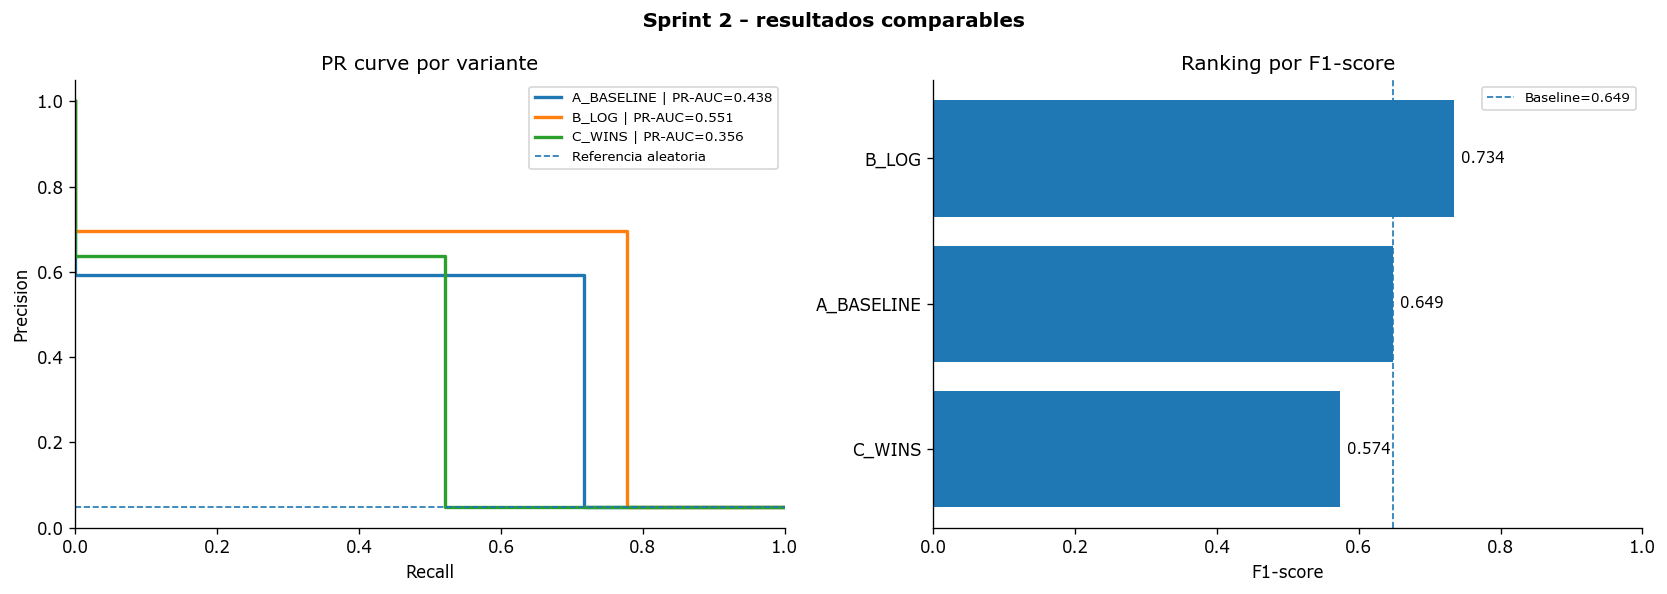

Mejor variante preliminar: B_LOG


,pred_no_outlier,pred_outlier
real_no_outlier,109082,1947
real_outlier,1270,4430


Figura guardada: outputs_sprint2\figuras\sprint2_pr_curve_ranking.png


In [11]:
# =============================================================================
# 7. GRAFICOS DE RESULTADOS Y MATRIZ DE CONFUSION
# =============================================================================

y_true_test = test_df["y_true"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for variante, pred in predicciones.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_true_test, pred)
    pr_auc = average_precision_score(y_true_test, pred)
    axes[0].step(
        recall_curve,
        precision_curve,
        where="post",
        linewidth=2,
        label=f"{variante} | PR-AUC={pr_auc:.3f}",
    )

axes[0].axhline(y_true_test.mean(), linestyle="--", linewidth=1, label="Referencia aleatoria")
axes[0].set_title("PR curve por variante")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)

ranking = tabla_resultados.sort_values("f1", ascending=True)
axes[1].barh(ranking["variante"], ranking["f1"])
for i, valor in enumerate(ranking["f1"]):
    axes[1].text(valor + 0.01, i, f"{valor:.3f}", va="center", fontsize=9)
axes[1].axvline(baseline_f1, linestyle="--", linewidth=1, label=f"Baseline={baseline_f1:.3f}")
axes[1].set_title("Ranking por F1-score")
axes[1].set_xlabel("F1-score")
axes[1].set_xlim(0, max(1.0, ranking["f1"].max() + 0.15))
axes[1].legend(fontsize=8)

plt.suptitle("Sprint 2 - resultados comparables", fontweight="bold")
plt.tight_layout()
FIG_ABLATION_PATH = FIG_DIR / "sprint2_pr_curve_ranking.png"
plt.savefig(FIG_ABLATION_PATH, dpi=120, bbox_inches="tight")
plt.show()

# Matriz de confusion de la mejor variante
mejor_variante = tabla_resultados.iloc[0]["variante"]
cm = confusion_matrix(y_true_test, predicciones[mejor_variante], labels=[0, 1])
tabla_cm = pd.DataFrame(
    cm,
    index=["real_no_outlier", "real_outlier"],
    columns=["pred_no_outlier", "pred_outlier"],
)

print(f"Mejor variante preliminar: {mejor_variante}")
display(tabla_cm)
print(f"Figura guardada: {FIG_ABLATION_PATH}")

In [ ]:
# =============================================================================
# 8. CROSS-VALIDATION POR SUBPARTIDA
# =============================================================================

def crear_folds_cv_por_subpartida(df_base: pd.DataFrame) -> list[tuple[pd.DataFrame, pd.DataFrame, int, str]]:
    """
    Crea folds de cross-validation dentro de cada subpartida.

    Parameters
    ----------
    df_base : pd.DataFrame
        Dataset preparado con y_true.

    Returns
    -------
    list[tuple[pd.DataFrame, pd.DataFrame, int, str]]
        Lista de tuplas con train, test, fold_id y subpartida.

    Raises
    ------
    ValueError
        Si no se pudieron crear folds validos.
    """
    columnas_requeridas = [COL_GRUPO, "VU", "LOG_VU", "LOG_FOB", "y_true"]
    faltantes = [columna for columna in columnas_requeridas if columna not in df_base.columns]
    if faltantes:
        raise ValueError(f"Columnas faltantes para CV: {faltantes}")

    folds_cv = []
    subpartidas_omitidas = []

    for subpartida, df_sub in df_base.groupby(COL_GRUPO):
        df_sub = df_sub.copy().reset_index(drop=True)

        if len(df_sub) < MIN_REGISTROS_CV:
            subpartidas_omitidas.append(str(subpartida))
            continue

        n_folds_sub = min(N_FOLDS_CV, len(df_sub))
        tiene_dos_clases = df_sub["y_true"].nunique() >= 2
        clase_minima = df_sub["y_true"].value_counts().min()

        if tiene_dos_clases and clase_minima >= n_folds_sub:
            splitter = StratifiedKFold(n_splits=n_folds_sub, shuffle=True, random_state=SEED)
            splits = splitter.split(df_sub, df_sub["y_true"])
        else:
            splitter = KFold(n_splits=n_folds_sub, shuffle=True, random_state=SEED)
            splits = splitter.split(df_sub)

        for fold_id, (idx_train, idx_test) in enumerate(splits, start=1):
            folds_cv.append((
                df_sub.iloc[idx_train].copy(),
                df_sub.iloc[idx_test].copy(),
                fold_id,
                str(subpartida),
            ))

    if not folds_cv:
        raise ValueError("No se pudo crear cross-validation por subpartida.")

    print("Cross-validation por subpartida definido")
    print("=" * 80)
    print(f"Folds generados       : {len(folds_cv):,}")
    print(f"Subpartidas omitidas  : {len(subpartidas_omitidas):,}")

    return folds_cv

folds_cv = crear_folds_cv_por_subpartida(df_eval)

resultados_cv = []

for train_cv, test_cv, fold_id, subpartida in folds_cv:
    for variante in VARIANTES:
        metricas, _ = ejecutar_variante(train_cv, test_cv, variante)
        metricas.update({
            "fold": fold_id,
            "subpartida": subpartida,
            "registros_train": len(train_cv),
            "registros_test": len(test_cv),
            "outlier_rate_test": test_cv["y_true"].mean(),
        })
        resultados_cv.append(metricas)

tabla_cv_detalle = pd.DataFrame(resultados_cv)

tabla_cv_resumen = (
    tabla_cv_detalle
    .groupby("variante")
    .agg(
        f1_promedio=("f1", "mean"),
        f1_std=("f1", "std"),
        precision_promedio=("precision", "mean"),
        recall_promedio=("recall", "mean"),
        pr_auc_promedio=("pr_auc", "mean"),
        latencia_ms_promedio=("latencia_ms", "mean"),
        folds_evaluados=("fold", "count"),
    )
    .reset_index()
)

baseline_cv = float(tabla_cv_resumen.loc[tabla_cv_resumen["variante"] == "A_BASELINE", "f1_promedio"].iloc[0])
tabla_cv_resumen["mejora_vs_baseline_cv"] = tabla_cv_resumen["f1_promedio"] - baseline_cv
tabla_cv_resumen = tabla_cv_resumen.sort_values("f1_promedio", ascending=False).reset_index(drop=True)

tabla_cv_subpartida = (
    tabla_cv_detalle
    .groupby(["subpartida", "variante"])
    .agg(
        f1_promedio_subpartida=("f1", "mean"),
        precision_promedio_subpartida=("precision", "mean"),
        recall_promedio_subpartida=("recall", "mean"),
        pr_auc_promedio_subpartida=("pr_auc", "mean"),
        folds=("fold", "count"),
        registros_test_total=("registros_test", "sum"),
    )
    .reset_index()
)

for col in [
    "f1_promedio",
    "f1_std",
    "precision_promedio",
    "recall_promedio",
    "pr_auc_promedio",
    "latencia_ms_promedio",
    "mejora_vs_baseline_cv",
]:
    tabla_cv_resumen[col] = tabla_cv_resumen[col].astype(float).round(4)

for col in [
    "f1_promedio_subpartida",
    "precision_promedio_subpartida",
    "recall_promedio_subpartida",
    "pr_auc_promedio_subpartida",
]:
    tabla_cv_subpartida[col] = tabla_cv_subpartida[col].astype(float).round(4)

tabla_cv_resumen

In [ ]:
# =============================================================================
# 9. ESTABILIDAD POR SUBPARTIDA
# =============================================================================

# Tabla ancha para comparar variantes dentro de cada subpartida.
tabla_estabilidad_subpartida = tabla_cv_subpartida.pivot_table(
    index="subpartida",
    columns="variante",
    values="f1_promedio_subpartida",
    aggfunc="mean",
).reset_index()

if "A_BASELINE" in tabla_estabilidad_subpartida.columns:
    for variante in ["B_LOG", "C_WINS"]:
        if variante in tabla_estabilidad_subpartida.columns:
            tabla_estabilidad_subpartida[f"mejora_{variante}_vs_baseline"] = (
                tabla_estabilidad_subpartida[variante] - tabla_estabilidad_subpartida["A_BASELINE"]
            )

columnas_mejora = [col for col in tabla_estabilidad_subpartida.columns if col.startswith("mejora_")]
for col in columnas_mejora:
    tabla_estabilidad_subpartida[col] = tabla_estabilidad_subpartida[col].astype(float).round(4)

resumen_estabilidad = []
for variante in ["B_LOG", "C_WINS"]:
    col_mejora = f"mejora_{variante}_vs_baseline"
    if col_mejora in tabla_estabilidad_subpartida.columns:
        serie = tabla_estabilidad_subpartida[col_mejora].dropna()
        resumen_estabilidad.append({
            "variante": variante,
            "subpartidas_con_mejora": int((serie > 0).sum()),
            "subpartidas_sin_mejora": int((serie <= 0).sum()),
            "mejora_promedio": float(serie.mean()) if len(serie) else 0.0,
            "mejora_mediana": float(serie.median()) if len(serie) else 0.0,
        })

tabla_resumen_estabilidad = pd.DataFrame(resumen_estabilidad)
for col in ["mejora_promedio", "mejora_mediana"]:
    if col in tabla_resumen_estabilidad.columns:
        tabla_resumen_estabilidad[col] = tabla_resumen_estabilidad[col].round(4)

print("Resumen de estabilidad por subpartida")
display(tabla_resumen_estabilidad)

tabla_estabilidad_subpartida.head(20)

In [ ]:
# =============================================================================
# 10. CURVA DE APRENDIZAJE / ESTABILIDAD PARA LA MEJOR VARIANTE
# =============================================================================

def muestrear_train_por_subpartida(train: pd.DataFrame, proporcion: float) -> pd.DataFrame:
    """
    Obtiene una muestra de train manteniendo la logica por subpartida.

    Parameters
    ----------
    train : pd.DataFrame
        Dataset de entrenamiento original.
    proporcion : float
        Proporcion de registros a usar por subpartida.

    Returns
    -------
    pd.DataFrame
        Muestra de entrenamiento por subpartida.
    """
    muestras = []
    for _, df_sub in train.groupby(COL_GRUPO):
        n_muestra = max(5, int(np.ceil(len(df_sub) * proporcion)))
        n_muestra = min(n_muestra, len(df_sub))
        muestras.append(df_sub.sample(n=n_muestra, random_state=SEED))
    return pd.concat(muestras, ignore_index=True)


def calcular_curva_estabilidad(train: pd.DataFrame, test: pd.DataFrame, variante: str) -> pd.DataFrame:
    """
    Calcula metrica de test usando tamanos crecientes de train.

    Parameters
    ----------
    train : pd.DataFrame
        Dataset de entrenamiento completo.
    test : pd.DataFrame
        Dataset de prueba fijo.
    variante : str
        Variante a evaluar.

    Returns
    -------
    pd.DataFrame
        Tabla con train_size, precision, recall, f1 y pr_auc.
    """
    filas = []
    for proporcion in LEARNING_TRAIN_SIZES:
        train_muestra = muestrear_train_por_subpartida(train, proporcion)
        metricas, _ = ejecutar_variante(train_muestra, test, variante)
        filas.append({
            "variante": variante,
            "train_size_pct": proporcion,
            "registros_train": len(train_muestra),
            "precision": metricas["precision"],
            "recall": metricas["recall"],
            "f1": metricas["f1"],
            "pr_auc": metricas["pr_auc"],
        })
    return pd.DataFrame(filas)

variante_ganadora_cv = tabla_cv_resumen.iloc[0]["variante"]
tabla_learning = calcular_curva_estabilidad(train_df, test_df, variante_ganadora_cv)

tabla_learning_round = tabla_learning.copy()
for col in ["train_size_pct", "precision", "recall", "f1", "pr_auc"]:
    tabla_learning_round[col] = tabla_learning_round[col].astype(float).round(4)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tabla_learning["train_size_pct"] * 100, tabla_learning["f1"], marker="o", label="F1 test")
ax.plot(tabla_learning["train_size_pct"] * 100, tabla_learning["pr_auc"], marker="o", label="PR-AUC test")
ax.set_title(f"Curva de estabilidad - {variante_ganadora_cv}")
ax.set_xlabel("Porcentaje de train usado")
ax.set_ylabel("Metrica")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
FIG_LEARNING_PATH = FIG_DIR / "sprint2_learning_curve_estabilidad.png"
plt.savefig(FIG_LEARNING_PATH, dpi=120, bbox_inches="tight")
plt.show()

print(f"Figura guardada: {FIG_LEARNING_PATH}")
tabla_learning_round

In [ ]:
# =============================================================================
# 11. MODELO AUXILIAR PARA IMPORTANCIA DE VARIABLES Y CALIBRACION
# =============================================================================

def crear_features_auxiliares(train: pd.DataFrame, test: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    """
    Crea features auxiliares ajustadas solo con train.

    Parameters
    ----------
    train : pd.DataFrame
        Dataset de entrenamiento.
    test : pd.DataFrame
        Dataset de prueba.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame, list[str]]
        Matrices train/test con features y lista de columnas usadas.
    """
    train_x = train.copy()
    test_x = test.copy()

    # Estadisticos por subpartida aprendidos solo con train.
    stats_grupo = train_x.groupby(COL_GRUPO).agg(
        mediana_vu_train=("VU", "median"),
        media_vu_train=("VU", "mean"),
        std_vu_train=("VU", "std"),
        registros_grupo_train=("VU", "size"),
    ).reset_index()
    stats_grupo["std_vu_train"] = stats_grupo["std_vu_train"].replace(0, np.nan)

    # Frecuencia de aduana aprendida solo con train.
    freq_aduana = (
        train_x[COL_ADUANA]
        .value_counts(normalize=True)
        .rename_axis(COL_ADUANA)
        .reset_index(name="aduana_freq_train")
    )

    train_x = train_x.merge(stats_grupo, on=COL_GRUPO, how="left")
    test_x = test_x.merge(stats_grupo, on=COL_GRUPO, how="left")
    train_x = train_x.merge(freq_aduana, on=COL_ADUANA, how="left")
    test_x = test_x.merge(freq_aduana, on=COL_ADUANA, how="left")

    for df_tmp in [train_x, test_x]:
        df_tmp["mediana_vu_train"] = df_tmp["mediana_vu_train"].fillna(train_x["VU"].median())
        df_tmp["media_vu_train"] = df_tmp["media_vu_train"].fillna(train_x["VU"].mean())
        df_tmp["std_vu_train"] = df_tmp["std_vu_train"].fillna(train_x["VU"].std())
        df_tmp["registros_grupo_train"] = df_tmp["registros_grupo_train"].fillna(0)
        df_tmp["aduana_freq_train"] = df_tmp["aduana_freq_train"].fillna(0)
        df_tmp["ratio_vu_mediana_train"] = df_tmp["VU"] / df_tmp["mediana_vu_train"].replace(0, np.nan)
        df_tmp["z_relativo_train"] = (df_tmp["VU"] - df_tmp["media_vu_train"]) / df_tmp["std_vu_train"].replace(0, np.nan)
        df_tmp.replace([np.inf, -np.inf], np.nan, inplace=True)
        df_tmp.fillna(0, inplace=True)

    feature_cols = [
        "VU",
        "LOG_VU",
        COL_FOB,
        "LOG_FOB",
        "ratio_vu_mediana_train",
        "z_relativo_train",
        "aduana_freq_train",
        "registros_grupo_train",
    ]

    return train_x[feature_cols], test_x[feature_cols], feature_cols


def entrenar_modelo_auxiliar(train: pd.DataFrame, test: pd.DataFrame) -> tuple[RandomForestClassifier, pd.DataFrame, pd.DataFrame, list[str]]:
    """
    Entrena un RandomForest auxiliar para diagnostico de importancia.

    Parameters
    ----------
    train : pd.DataFrame
        Dataset de entrenamiento.
    test : pd.DataFrame
        Dataset de prueba.

    Returns
    -------
    tuple[RandomForestClassifier, pd.DataFrame, pd.DataFrame, list[str]]
        Modelo entrenado, X_train, X_test y columnas de features.
    """
    x_train, x_test, feature_cols = crear_features_auxiliares(train, test)
    y_train = train["y_true"].to_numpy()

    modelo = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1,
    )
    modelo.fit(x_train, y_train)
    return modelo, x_train, x_test, feature_cols

modelo_aux, x_train_aux, x_test_aux, feature_cols_aux = entrenar_modelo_auxiliar(train_df, test_df)
prob_aux = modelo_aux.predict_proba(x_test_aux)[:, 1]
pred_aux = (prob_aux >= 0.50).astype(int)

metricas_aux = evaluar_prediccion(y_true_test, pred_aux)
metricas_aux["brier_score"] = brier_score_loss(y_true_test, prob_aux)

importancia_rf = pd.DataFrame({
    "feature": feature_cols_aux,
    "importance_rf": modelo_aux.feature_importances_,
}).sort_values("importance_rf", ascending=False)

try:
    perm = permutation_importance(
        modelo_aux,
        x_test_aux,
        y_true_test,
        n_repeats=5,
        random_state=SEED,
        scoring="f1",
    )
    importancia_perm = pd.DataFrame({
        "feature": feature_cols_aux,
        "importance_permutation_mean": perm.importances_mean,
        "importance_permutation_std": perm.importances_std,
    })
    tabla_importancia = importancia_rf.merge(importancia_perm, on="feature", how="left")
except Exception as exc:
    print(f"No se pudo calcular permutation importance: {exc}")
    tabla_importancia = importancia_rf.copy()
    tabla_importancia["importance_permutation_mean"] = np.nan
    tabla_importancia["importance_permutation_std"] = np.nan

tabla_importancia_round = tabla_importancia.copy()
for col in ["importance_rf", "importance_permutation_mean", "importance_permutation_std"]:
    tabla_importancia_round[col] = tabla_importancia_round[col].astype(float).round(6)

print("Metricas del modelo auxiliar RandomForest")
print(json.dumps({k: round(float(v), 4) for k, v in metricas_aux.items()}, indent=4))

tabla_importancia_round

In [ ]:
# =============================================================================
# 12. CALIBRACION DEL MODELO AUXILIAR
# =============================================================================

frac_pos, mean_pred = calibration_curve(y_true_test, prob_aux, n_bins=10, strategy="quantile")

tabla_calibracion = pd.DataFrame({
    "probabilidad_media_predicha": mean_pred,
    "frecuencia_real_outlier": frac_pos,
})

tabla_calibracion_round = tabla_calibracion.copy()
for col in tabla_calibracion_round.columns:
    tabla_calibracion_round[col] = tabla_calibracion_round[col].astype(float).round(4)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred, frac_pos, marker="o", label="Modelo auxiliar")
ax.plot([0, 1], [0, 1], linestyle="--", label="Calibracion perfecta")
ax.set_title(f"Calibracion RandomForest auxiliar | Brier={metricas_aux['brier_score']:.4f}")
ax.set_xlabel("Probabilidad media predicha")
ax.set_ylabel("Frecuencia real de outlier")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
FIG_CALIBRATION_PATH = FIG_DIR / "sprint2_calibracion_modelo_auxiliar.png"
plt.savefig(FIG_CALIBRATION_PATH, dpi=120, bbox_inches="tight")
plt.show()

print(f"Figura guardada: {FIG_CALIBRATION_PATH}")
tabla_calibracion_round

In [ ]:
# =============================================================================
# 13. MATRIZ DE DECISION FINAL
# =============================================================================

mejor_ablation = tabla_resultados.iloc[0]
mejor_cv = tabla_cv_resumen.iloc[0]
variante_adoptada = mejor_cv["variante"]

matriz_decision = []
for _, fila in tabla_cv_resumen.iterrows():
    variante = fila["variante"]
    f1_ab = float(tabla_resultados.loc[tabla_resultados["variante"] == variante, "f1"].iloc[0])
    lat_ab = float(tabla_resultados.loc[tabla_resultados["variante"] == variante, "latencia_ms"].iloc[0])

    mejora_cv = float(fila["mejora_vs_baseline_cv"])
    std_cv = float(fila["f1_std"])

    if variante == "A_BASELINE":
        decision = "referencia"
    elif variante == variante_adoptada and mejora_cv >= 0:
        decision = "adoptar"
    elif mejora_cv > 0:
        decision = "candidato alternativo"
    else:
        decision = "descartar"

    matriz_decision.append({
        "variante": variante,
        "f1_holdout": f1_ab,
        "f1_cv_promedio": float(fila["f1_promedio"]),
        "f1_cv_std": std_cv,
        "mejora_vs_baseline_cv": mejora_cv,
        "latencia_ms_holdout": lat_ab,
        "sin_leakage": "OK",
        "split_correcto": "OK",
        "interpretabilidad": "alta",
        "decision": decision,
    })

tabla_matriz_decision = pd.DataFrame(matriz_decision)
for col in ["f1_holdout", "f1_cv_promedio", "f1_cv_std", "mejora_vs_baseline_cv", "latencia_ms_holdout"]:
    tabla_matriz_decision[col] = tabla_matriz_decision[col].astype(float).round(4)

conclusion_final = (
    f"Se adopta {variante_adoptada} porque presenta el mejor desempeno promedio "
    f"en cross-validation por subpartida, mantiene el protocolo sin leakage, "
    f"usa el mismo dataset que el baseline y conserva interpretabilidad tecnica."
)

print(conclusion_final)
tabla_matriz_decision

In [ ]:
# =============================================================================
# 14. EXPORTACION DE LOGS Y README DE REPRODUCIBILIDAD
# =============================================================================

fecha_ejecucion = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Exportar logs con separador pipe.
tabla_resultados_export = tabla_resultados_round.copy()
tabla_resultados_export.insert(0, "fecha_ejecucion", fecha_ejecucion)
tabla_resultados_export.insert(1, "seed", SEED)
tabla_resultados_export.insert(2, "split", TIPO_SPLIT)
tabla_resultados_export.insert(3, "periodo", f"{FEC_INI} a {FEC_FIN}")
tabla_resultados_export.insert(4, "hash_snapshot_sha256", HASH_SNAPSHOT)
tabla_resultados_export.to_csv(LOG_EXPERIMENTOS_CSV, index=False, sep="|", encoding="utf-8")

tabla_cv_detalle.to_csv(LOG_CV_CSV, index=False, sep="|", encoding="utf-8")
tabla_cv_subpartida.to_csv(LOG_CV_SUBPARTIDA_CSV, index=False, sep="|", encoding="utf-8")
tabla_learning_round.to_csv(LOG_LEARNING_CSV, index=False, sep="|", encoding="utf-8")
tabla_importancia_round.to_csv(LOG_IMPORTANCIA_CSV, index=False, sep="|", encoding="utf-8")

readme = f"""
ENTREGA SPRINT 2 - REPRODUCIBILIDAD

Comando sugerido:
    jupyter notebook sprint2_validacion_completa_valores_unitarios.ipynb

Parametros:
    seed={SEED}
    periodo={FEC_INI} a {FEC_FIN}
    split={TIPO_SPLIT}
    test_size={TEST_SIZE}
    umbral_z_robusto={UMBRAL_Z_ROBUSTO_GT}
    metrica_principal=F1-score
    metricas_secundarias=precision, recall, PR-AUC, detectados, tasa_detectada, latencia_ms

Protocolo:
    1. Carga unica de datos desde SQL Server.
    2. Snapshot con hash SHA256 antes de evaluar variantes.
    3. Split dentro de cada subpartida.
    4. Ajustes calculados solo con train.
    5. Evaluacion en test fijo para todas las variantes.
    6. Cross-validation por subpartida para estabilidad.
    7. Modelo auxiliar solo para importancia y calibracion.

Archivos generados:
    snapshot={SNAPSHOT_PATH}
    metricas_ablation={LOG_EXPERIMENTOS_CSV}
    metricas_cv={LOG_CV_CSV}
    metricas_cv_subpartida={LOG_CV_SUBPARTIDA_CSV}
    learning_curve={LOG_LEARNING_CSV}
    importancia_features={LOG_IMPORTANCIA_CSV}
    figura_ablation={FIG_ABLATION_PATH}
    figura_learning={FIG_LEARNING_PATH}
    figura_calibracion={FIG_CALIBRATION_PATH}

Hash snapshot SHA256:
    {HASH_SNAPSHOT}

Decision tecnica:
    adoptar={variante_adoptada}
    f1_cv_promedio={float(mejor_cv['f1_promedio']):.4f}
    f1_cv_std={float(mejor_cv['f1_std']):.4f}
    mejora_vs_baseline_cv={float(mejor_cv['mejora_vs_baseline_cv']):.4f}

Conclusion:
    {conclusion_final}

Riesgos y siguientes pasos:
    1. La etiqueta y_true es proxy estadistica; requiere validacion experta.
    2. Monitorear drift por subpartida y aduana antes de produccion.
    3. Revisar falsos positivos por familia de producto y composicion declarada.
""".strip()
README_PATH.write_text(readme, encoding="utf-8")

print("LOGS EXPORTADOS")
print("=" * 80)
print(f"Ablation        : {LOG_EXPERIMENTOS_CSV}")
print(f"CV detalle      : {LOG_CV_CSV}")
print(f"CV subpartida   : {LOG_CV_SUBPARTIDA_CSV}")
print(f"Learning curve  : {LOG_LEARNING_CSV}")
print(f"Importancia     : {LOG_IMPORTANCIA_CSV}")
print(f"README          : {README_PATH}")

In [ ]:
# =============================================================================
# 15. CHECKLIST FINAL SPRINT 2
# =============================================================================

checklist = pd.DataFrame([
    {
        "item_validacion": "Split correcto por subpartida",
        "estado": "OK",
        "evidencia": TIPO_SPLIT,
    },
    {
        "item_validacion": "Fit solo en train",
        "estado": "OK",
        "evidencia": "IQR, P5/P95 y features auxiliares se ajustan solo con train",
    },
    {
        "item_validacion": "Seeds fijadas",
        "estado": "OK",
        "evidencia": f"SEED={SEED}",
    },
    {
        "item_validacion": "Mismo protocolo que Semana 5 / Semana 6",
        "estado": "OK",
        "evidencia": "Mismo dataset, misma etiqueta proxy y mismas metricas base",
    },
    {
        "item_validacion": "Sin cambios de data entre baseline y evaluacion final",
        "estado": "OK",
        "evidencia": f"Hash snapshot={HASH_SNAPSHOT}",
    },
    {
        "item_validacion": "Logs completos",
        "estado": "OK",
        "evidencia": "Config, metricas, timestamp, hash y README exportados",
    },
    {
        "item_validacion": "Ablation study",
        "estado": "OK",
        "evidencia": "A_BASELINE vs B_LOG vs C_WINS",
    },
    {
        "item_validacion": "Estabilidad entre folds",
        "estado": "OK",
        "evidencia": "Cross-validation por subpartida ejecutada",
    },
    {
        "item_validacion": "Diagnosticos",
        "estado": "OK",
        "evidencia": "PR curve, matriz de confusion, curva de estabilidad, importancia y calibracion auxiliar",
    },
])

checklist.to_csv(CHECKLIST_PATH, index=False, sep="|", encoding="utf-8")

print("CHECKLIST FINAL SPRINT 2")
print("=" * 80)
print(f"Archivo checklist: {CHECKLIST_PATH}")
checklist

## Cierre tecnico

La entrega queda estructurada para responder directamente al Sprint 2:

- Se mantiene el mismo dataset entre baseline y evaluacion final.
- Se evita leakage porque los parametros se ajustan solo con train.
- Se valida por subpartida porque cada producto tiene distribucion propia.
- Se compara baseline contra variantes mediante evidencia.
- Se agrega cross-validation, curva de estabilidad, importancia de variables y calibracion auxiliar.
- Se exportan logs completos para reproducibilidad.